In [1]:
# imports des bibliothèques
import torch
import torch.nn as nn

import os
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("BASE_DIR :", BASE_DIR)

import pickle as pkl

import numpy as np
import pandas as pd
import random as rd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

BASE_DIR : c:\Users\rapha\OneDrive\Bureau\IODAA\Cours AgroParisTech\Projet fil rouge


In [2]:
os.chdir(BASE_DIR)
import models_raph
from models_raph import basic
from pathlib import Path
import utils

import sys

from utils import deep_models

sys.modules["deep_models"] = deep_models

os.chdir(BASE_DIR)

path_model_fnv_with_bert_base_uncased_10 = Path('models_raph/basic/fnv_with_bert-base-uncased_10.pth').resolve()
print(path_model_fnv_with_bert_base_uncased_10)

with open(str(path_model_fnv_with_bert_base_uncased_10), 'rb') as f:
    model = torch.load(f, map_location=torch.device('cpu'))
    print("model keys :", model.keys())

C:\Users\rapha\OneDrive\Bureau\IODAA\Cours AgroParisTech\Projet fil rouge\models_raph\basic\fnv_with_bert-base-uncased_10.pth


C:\Users\rapha\AppData\Local\Temp\ipykernel_18040\2753268984.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f, map_location=torch.device('cpu'))


model keys : dict_keys(['model_state_dict', 'model_class', 'history'])


In [3]:
state_dict = model['model_state_dict']

In [4]:
for key, value in state_dict.items():
    print(f"Layer: {key}", "\n", f"Shape: {value.shape}")

Layer: feature_extractor.embeddings.word_embeddings.weight 
 Shape: torch.Size([30522, 768])
Layer: feature_extractor.embeddings.position_embeddings.weight 
 Shape: torch.Size([512, 768])
Layer: feature_extractor.embeddings.token_type_embeddings.weight 
 Shape: torch.Size([2, 768])
Layer: feature_extractor.embeddings.LayerNorm.weight 
 Shape: torch.Size([768])
Layer: feature_extractor.embeddings.LayerNorm.bias 
 Shape: torch.Size([768])
Layer: feature_extractor.encoder.layer.0.attention.self.query.weight 
 Shape: torch.Size([768, 768])
Layer: feature_extractor.encoder.layer.0.attention.self.query.bias 
 Shape: torch.Size([768])
Layer: feature_extractor.encoder.layer.0.attention.self.key.weight 
 Shape: torch.Size([768, 768])
Layer: feature_extractor.encoder.layer.0.attention.self.key.bias 
 Shape: torch.Size([768])
Layer: feature_extractor.encoder.layer.0.attention.self.value.weight 
 Shape: torch.Size([768, 768])
Layer: feature_extractor.encoder.layer.0.attention.self.value.bias 
 Sha

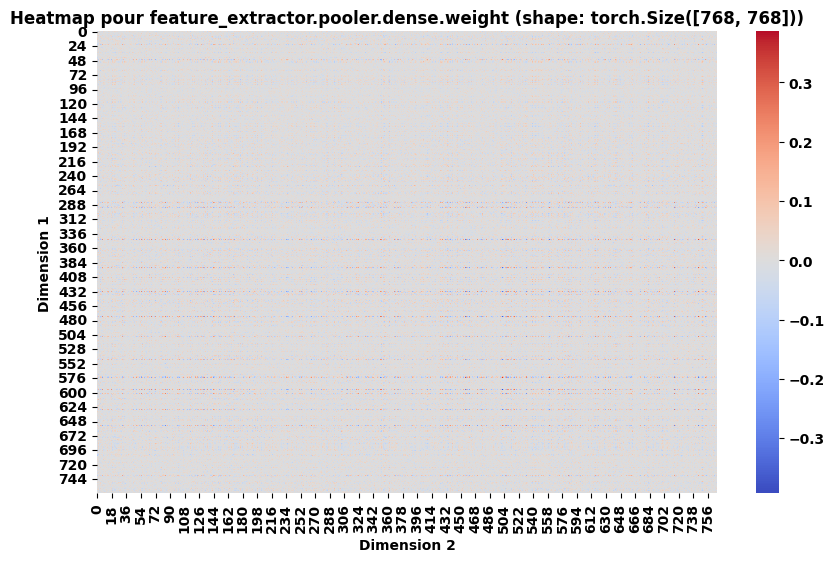

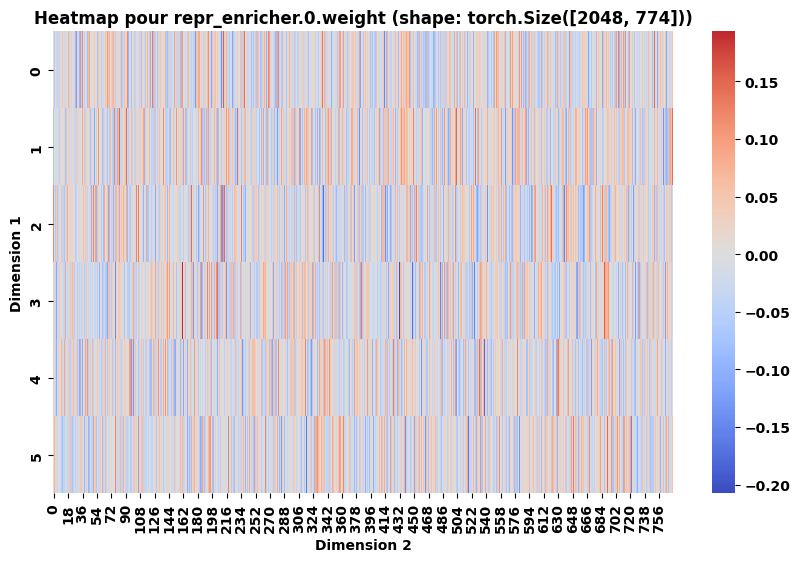

(6,)


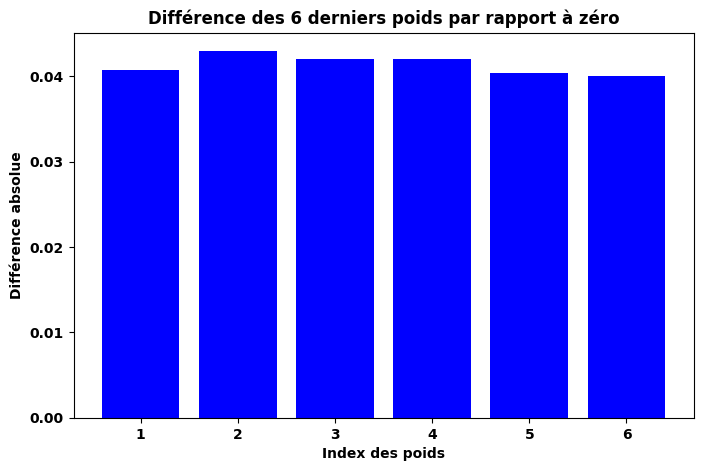

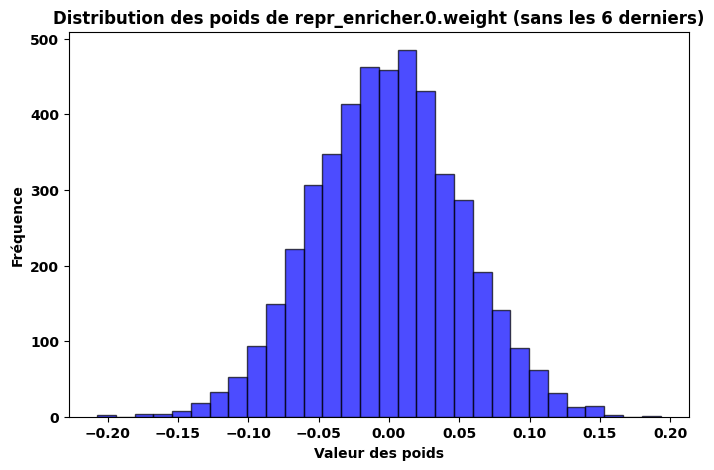

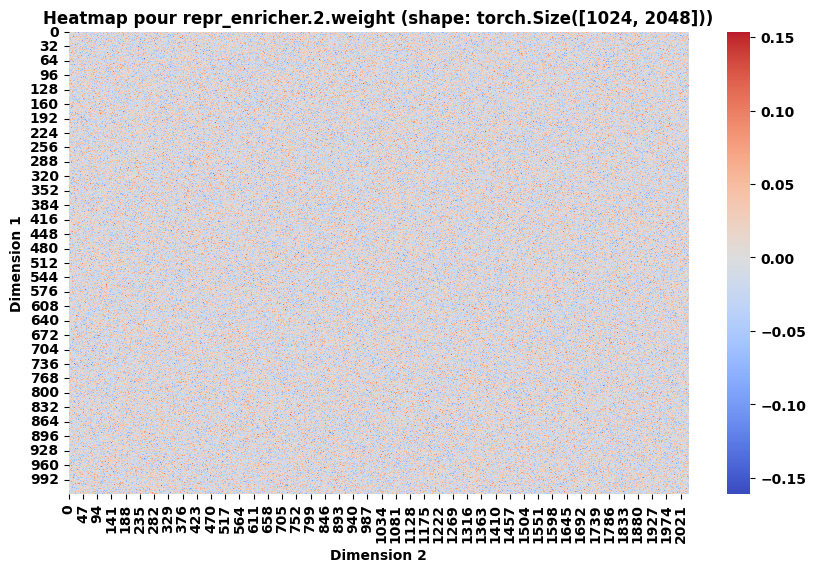

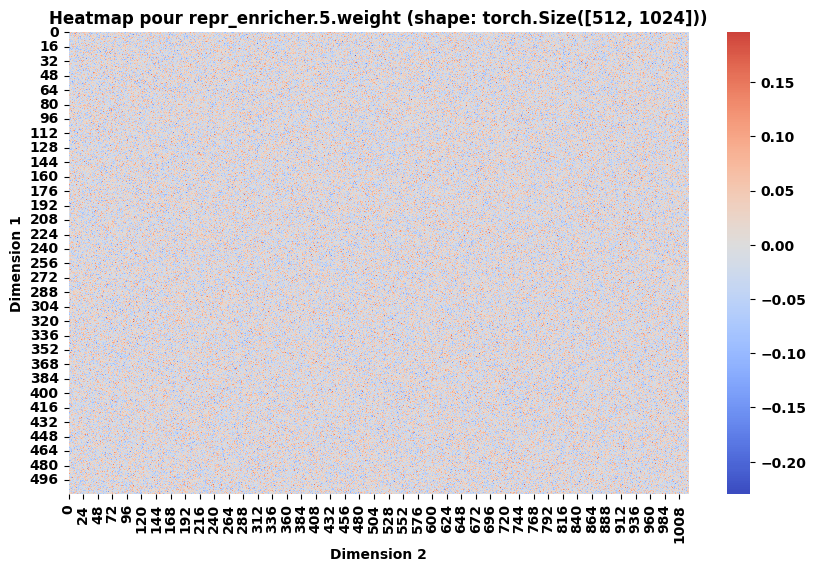

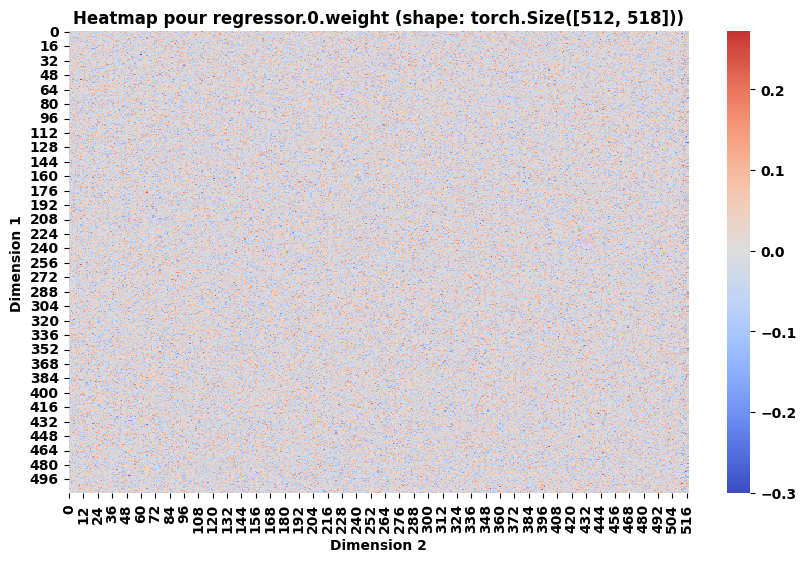

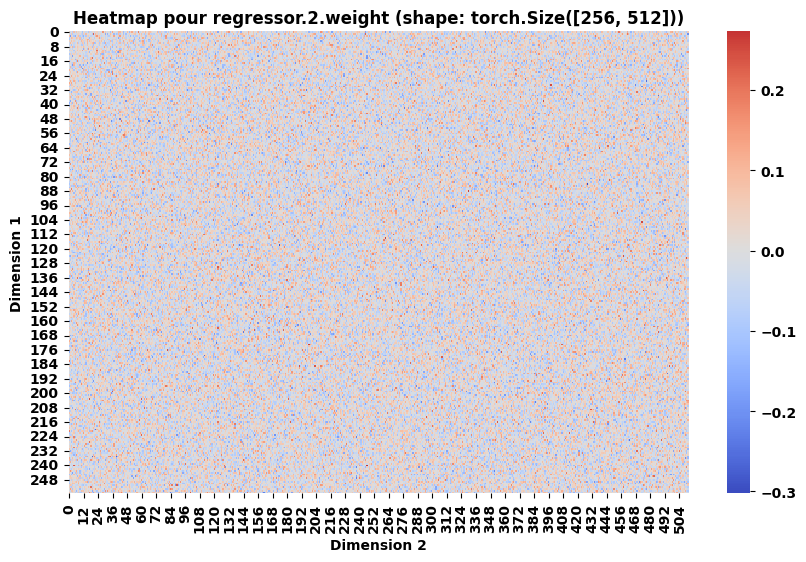

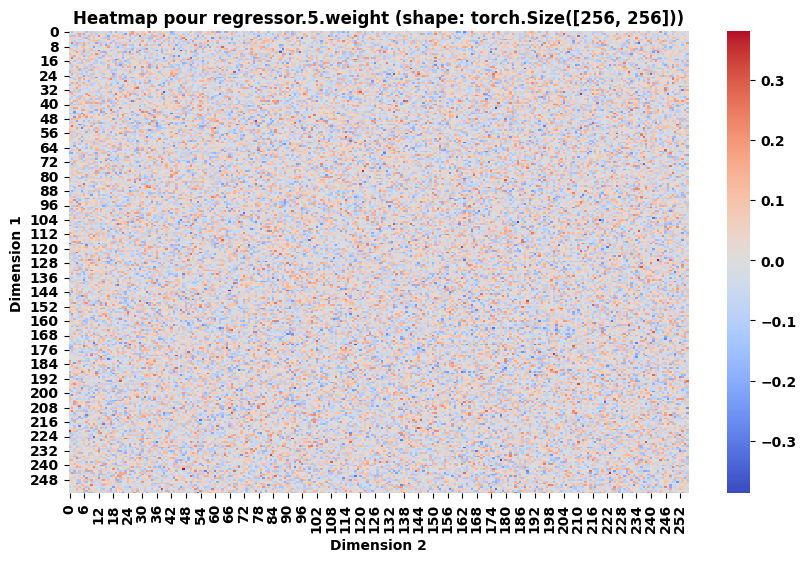

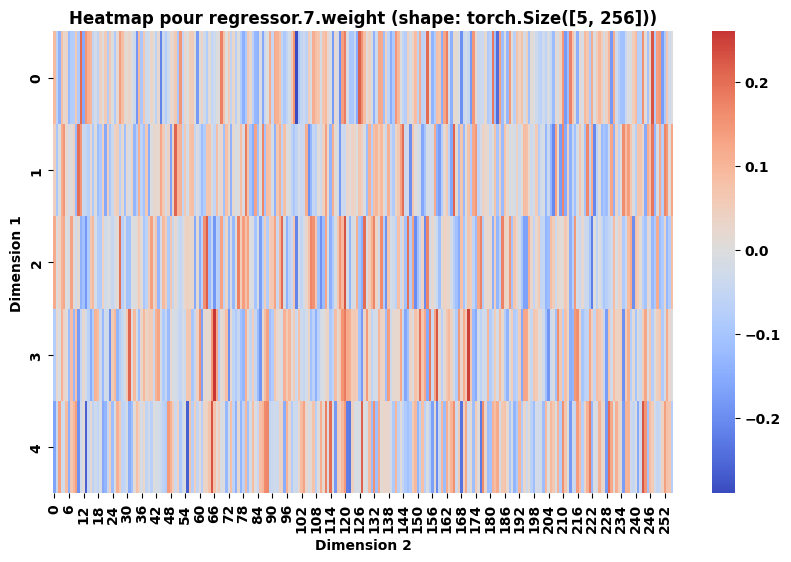

In [10]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  # Importation de numpy pour utiliser np.abs()

# Liste des couches de poids à afficher (on retire les biais)
layers_weights = [
    "feature_extractor.pooler.dense.weight",
    "repr_enricher.0.weight",
    "repr_enricher.2.weight",
    "repr_enricher.5.weight",
    "regressor.0.weight",
    "regressor.2.weight",
    "regressor.5.weight",
    "regressor.7.weight"
]

# Parcourir la liste et afficher la heatmap de chaque couche de poids
for layer in layers_weights:
    # Extraire le tenseur depuis le state_dict
    tensor = state_dict[layer]
    
    tensor_np_his = None  # Initialisation de tensor_np_his à None
    
    if layer == "repr_enricher.0.weight":
        # Pour repr_enricher.0.weight, on sélectionne les 6 derniers poids de la première dimension
        tensor_np = tensor.cpu().detach().numpy()[-6:]
        tensor_np_his = np.mean(np.abs(tensor.cpu().detach().numpy()[-6:]), 1)  # Utilisation de np.abs() pour numpy
        
    else:
        # Sinon, on convertit tout le tensor en numpy
        tensor_np = tensor.cpu().detach().numpy()
    
    # Création de la heatmap pour ce tenseur
    plt.figure(figsize=(10, 6))
    sns.heatmap(tensor_np, cmap="coolwarm", center=0)
    plt.title(f"Heatmap pour {layer} (shape: {tensor.shape})")
    plt.xlabel("Dimension 2")
    plt.ylabel("Dimension 1")
    plt.show()

    # Création de l'histogramme si nécessaire
    if tensor_np_his is not None:
        
        plt.figure(figsize=(8, 5))
        print(tensor_np_his.shape)
        plt.bar(range(1, 7), tensor_np_his.flatten(), color='blue')  # Utilisation de flatten pour aplatir le tensor
        plt.title('Différence des 6 derniers poids par rapport à zéro')
        plt.xlabel('Index des poids')
        plt.ylabel('Différence absolue')
        
        plt.figure(figsize=(8, 5))
        plt.hist(tensor_np.flatten(), bins=30, color='blue', edgecolor='black', alpha=0.7)
        plt.title(f'Distribution des poids de {layer} (sans les 6 derniers)')
        plt.xlabel('Valeur des poids')
        plt.ylabel('Fréquence')
        plt.show()
